In [73]:
import torch
import torch.nn as nn
import torch_geometric.nn as pygnn
import torch.nn.functional as F

In [109]:
class ChebNet(nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels, **kwargs):
        super().__init__(**kwargs)


        self.encoder = nn.Sequential(
            nn.Linear(in_features=in_channels,out_features=hidden_channels),
            nn.PReLU()
        )

        self.convs = pygnn.ChebConv(in_channels=hidden_channels, out_channels=hidden_channels, K=3)

        self.decoder = nn.Sequential(
            nn.Linear(in_features=hidden_channels,out_features=out_channels),
            nn.PReLU(),
            nn.Linear(in_features=out_channels,out_features=out_channels)
        )

        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.encoder(x)
        x = self.dropout(x)
        x = self.convs(x, edge_index)
        x = self.decoder(x)

        return x
    
    def get_negative_example(self, x):
        # Shuffles along the node dimension (node i gets features of j)
        n = x.shape[-2]
        perm = torch.randperm(n)
        x_ = x.clone()
        return x_[perm]

In [110]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

data = Planetoid(root=f'data/', name='cora', transform=NormalizeFeatures())

In [111]:
graph = data[0]

In [112]:
model = ChebNet(in_channels=1433, hidden_channels=512, out_channels=128)

In [113]:
class Discriminator(nn.Module):
    def __init__(self, dim):
        super(Discriminator, self).__init__()
        self.fn = nn.Bilinear(dim, dim, 1)

    def forward(self, h, c):
        c_x = c.expand_as(h)
        sc = self.fn(h, c_x).squeeze(1)
        return sc

In [114]:
disc = Discriminator(dim=128)

In [115]:
def get_graph_summary(x):
    return x.mean(dim=-2)

In [116]:
def contrastive_loss(H, H_tilde, s, D: Discriminator):
    embeddings = torch.cat((H, H_tilde), dim=0)
    return F.binary_cross_entropy_with_logits(
        D(embeddings, s),
        torch.cat((torch.ones(H.shape[0], device=s.device), 
                   torch.zeros(H.shape[0], device=s.device)))
    )

In [117]:
optim = torch.optim.Adam([{'params': model.parameters(), 'lr': 0.001},
                          {'params': disc.parameters(), 'lr': 0.001}])

In [118]:
epochs = 200
losses = []
for e in range(epochs):
    model.train()
    disc.train()
    optim.zero_grad()

    h = model(graph.x, graph.edge_index)
    h_tilde = model(model.get_negative_example(graph.x), graph.edge_index)

    s = get_graph_summary(h)

    loss = contrastive_loss(H=h, H_tilde=h_tilde, s=s, D=disc)

    loss.backward()
    optim.step()

    print(e, loss.item())
    losses.append(loss.item())

0 0.6931883692741394
1 0.6934236288070679
2 0.693156898021698
3 0.6931479573249817
4 0.6931734085083008
5 0.69316166639328
6 0.693123459815979
7 0.6930974721908569
8 0.6930919289588928
9 0.6930510997772217
10 0.6929746866226196
11 0.6928395628929138
12 0.6925937533378601
13 0.6922993063926697
14 0.6917241811752319
15 0.6907719373703003
16 0.6892712116241455
17 0.6872962713241577
18 0.684517502784729
19 0.6790295243263245
20 0.6860546469688416
21 0.6875666975975037
22 0.6693575382232666
23 0.6755478382110596
24 0.6738232970237732
25 0.6663971543312073
26 0.6734059453010559
27 0.6650859117507935
28 0.6612973809242249
29 0.6613065600395203
30 0.6550866961479187
31 0.6502538323402405
32 0.6419885754585266
33 0.648099958896637
34 0.637097179889679
35 0.6363009810447693
36 0.6320165395736694
37 0.6356823444366455
38 0.6133489608764648
39 0.6141697764396667
40 0.6098073124885559
41 0.6140896081924438
42 0.5950515866279602
43 0.6045495867729187
44 0.5945903062820435
45 0.5846958756446838
46 0.

In [119]:
import matplotlib.pyplot as plt

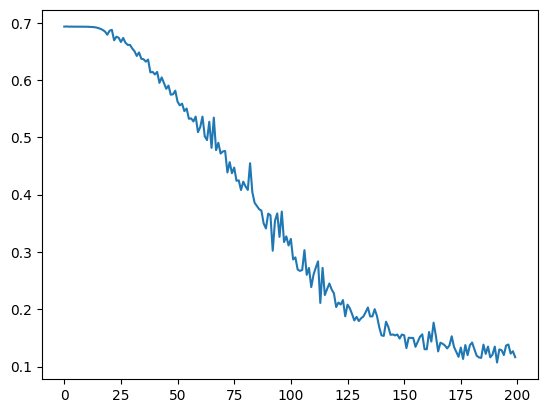

In [120]:
plt.plot(losses)